Las series temporales son omnipresentes en análisis financiero, monitoreo de sensores y planificación. Pandas y NumPy se integran con Matplotlib para convertir fechas, formatear ejes y resamplear tendencias.

10.1 Conversión de fechas con pd.to_datetime
Casos típicos: columnas de texto a datetime64[ns], detección automática o manual de formatos, manejo de valores inválidos (errors="coerce") y zonas horarias (tz_localize, tz_convert).

In [2]:
import pandas as pd

df = pd.DataFrame({
    "fecha": ["2025-01-01", "2025-01-02", "01/03/2025", "2025/01/04", "2025-13-01"],
    "valor": [10, 12, 11, 15, 14]
})

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce", dayfirst=False)
# df["fecha"] = pd.to_datetime(df["fecha"], format="%Y-%m-%d")  # Formato explícito

df = df.set_index("fecha").sort_index()

# df = df.tz_localize("UTC").tz_convert("America/Argentina/Cordoba")

💡 Tips: unificá la zona horaria, ordená con df.sort_index() y documentá la política de datos faltantes.

10.2 Gráficos de series de tiempo
Línea básica con Matplotlib (API OO)

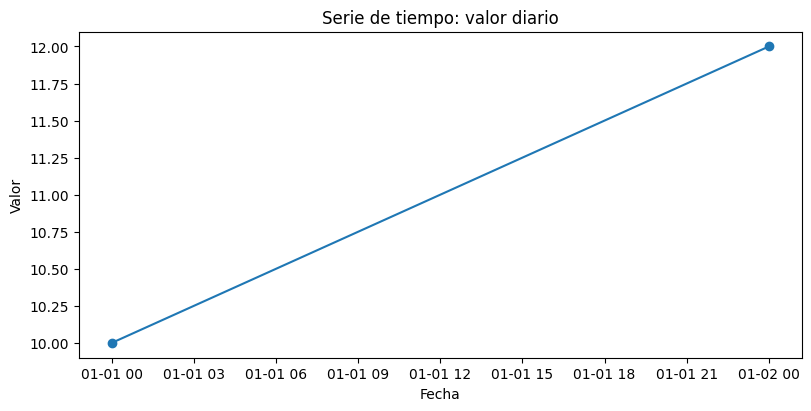

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({
    "fecha": ["2025-01-01", "2025-01-02", "01/03/2025", "2025/01/04", "2025-13-01"],
    "valor": [10, 12, 11, 15, 14]
})

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce", dayfirst=False)
# df["fecha"] = pd.to_datetime(df["fecha"], format="%Y-%m-%d")  # Formato explicito

df = df.set_index("fecha").sort_index()

# df = df.tz_localize("UTC").tz_convert("America/Argentina/Cordoba")

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.plot(df.index, df["valor"], marker="o")
ax.set_title("Serie de tiempo: valor diario")
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor")
plt.show()

Formateo de ejes de fecha

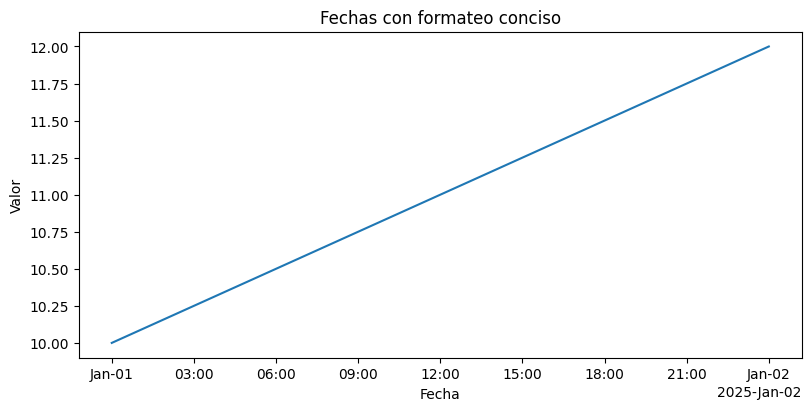

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

df = pd.DataFrame({
    "fecha": ["2025-01-01", "2025-01-02", "01/03/2025", "2025/01/04", "2025-13-01"],
    "valor": [10, 12, 11, 15, 14]
})

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce", dayfirst=False)
# df["fecha"] = pd.to_datetime(df["fecha"], format="%Y-%m-%d")  # Formato explicito

df = df.set_index("fecha").sort_index()

# df = df.tz_localize("UTC").tz_convert("America/Argentina/Cordoba")

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.plot(df.index, df["valor"])

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

ax.set_title("Fechas con formateo conciso")
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor")
plt.show()

Múltiples series y leyenda

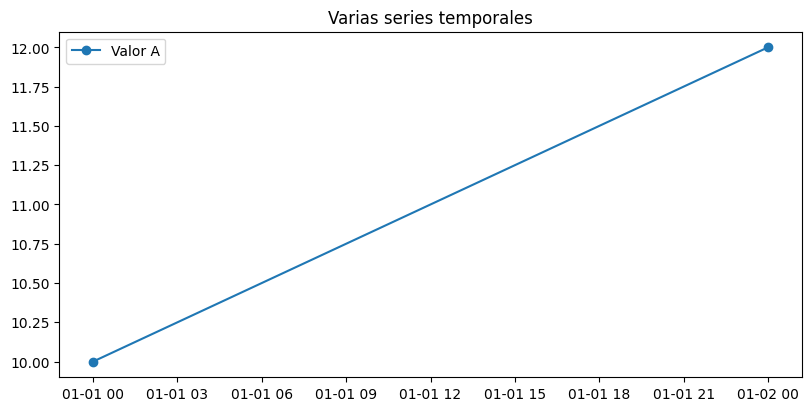

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({
    "fecha": ["2025-01-01", "2025-01-02", "01/03/2025", "2025/01/04", "2025-13-01"],
    "valor": [10, 12, 11, 15, 14]
})

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce", dayfirst=False)
# df["fecha"] = pd.to_datetime(df["fecha"], format="%Y-%m-%d")  # Formato explicito

df = df.set_index("fecha").sort_index()

# df = df.tz_localize("UTC").tz_convert("America/Argentina/Cordoba")

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.plot(df.index, df["valor"], label="Valor A", marker="o")
# ax.plot(df.index, df["valor_b"], label="Valor B", linestyle="--")
ax.legend()
ax.set_title("Varias series temporales")
plt.show()

10.3 Resampleo y tendencias
Resamplear cambia la frecuencia temporal (por ejemplo, diario a semanal/mensual) con una agregación. Las tendencias se observan con ventanas móviles, medianas o suavizados exponenciales.

Resampleo a semanal/mensual

In [ ]:
semana = df["valor"].resample("W").mean()
mes = df["valor"].resample("M").sum()

Ventanas móviles (rolling)

In [ ]:
media7 = df["valor"].rolling(window=7, center=True, min_periods=1).mean()
mediana7 = df["valor"].rolling(7, center=True, min_periods=1).median()

Suavizado exponencial (EWM)

In [ ]:
ewm14 = df["valor"].ewm(span=14, adjust=False).mean()

Tendencia integradora

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
ax.plot(df.index, df["valor"], alpha=0.4, label="Diario")
ax.plot(semana.index, semana, linewidth=2, label="Semanal (mean)")
ax.plot(media7.index, media7, linewidth=2, label="Media móvil 7D")
ax.plot(ewm14.index, ewm14, linewidth=2, label="EWM 14")
ax.set_title("Resampleo y tendencias")
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor")
ax.legend()
plt.show()

Resampleo mensual y suavizado

In [ ]:
mensual_mean = df["valor"].resample("M").mean()
mensual_mean_3 = mensual_mean.rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.plot(mensual_mean.index, mensual_mean, marker="o", label="Mensual (mean)")
ax.plot(mensual_mean_3.index, mensual_mean_3, label="Mensual suavizada (3M)")
ax.set_title("Promedio mensual y suavizado 3 meses")
ax.set_ylabel("Valor")
ax.legend()
plt.show()

Buenas prácticas (series temporales)
Usá DatetimeIndex, ordená con sort_index() y documentá la zona horaria.
Utilizá AutoDateLocator + ConciseDateFormatter para ejes limpios.
Explicá cada transformación (frecuencia W/M/Q, mean/sum, etc.).
Resampleá a periodos fijos para estudiar estacionalidad.
Definí la estrategia de valores faltantes antes de aplicar rolling o resample.